# Denoise the simulated image with N2V and different baselines

In [5]:
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import deepinv as dinv
from matplotlib import pyplot as plt
import os

In [2]:
path = '../data saved/'

stamps_ori = np.load(path + 'stampcor_bright.npy')
stamps_cle = np.load(path + 'stampcle_bright.npy')

In [3]:
os.chdir('../pn2v/src/pn2v')
from core import utils
from unet import UNet
from core import prediction
device = utils.getDevice()

os.chdir('../../..')
os.chdir('./model saved')

net=torch.load("N2V_simulation.net", weights_only=False)

CUDA available? True


In [4]:
num = 80
n2vResult = prediction.tiledPredict(stamps_ori[num], net ,ps=96, overlap=48,device=device, noiseModel=None)

In [6]:
bm3d = dinv.models.BM3D()
tgv = dinv.models.TGVDenoiser()
wavelet = dinv.models.WaveletDictDenoiser()
sigma = 3

In [7]:
ori = stamps_ori[num].copy()
ori = torch.from_numpy(ori)
ori = ori.unsqueeze(0)
ori = ori.unsqueeze(0).cuda()

cle = stamps_cle[num].copy()
cle = torch.from_numpy(cle)
cle = cle.unsqueeze(0)
cle = cle.unsqueeze(0).cuda()

In [8]:
imgs = [
    cle,
    ori,
    bm3d(ori, sigma),
    tgv(ori, sigma),
    wavelet(ori, sigma),
]

psnr = [dinv.metric.cal_psnr(cle, im).item() for im in imgs[1:]]
titles = ["Original", "Noisy", "BM3D", "TGV", "Wavelet"]
subtitles = ["PSNR:"] + [f"{p:.2f} dB" for p in psnr]

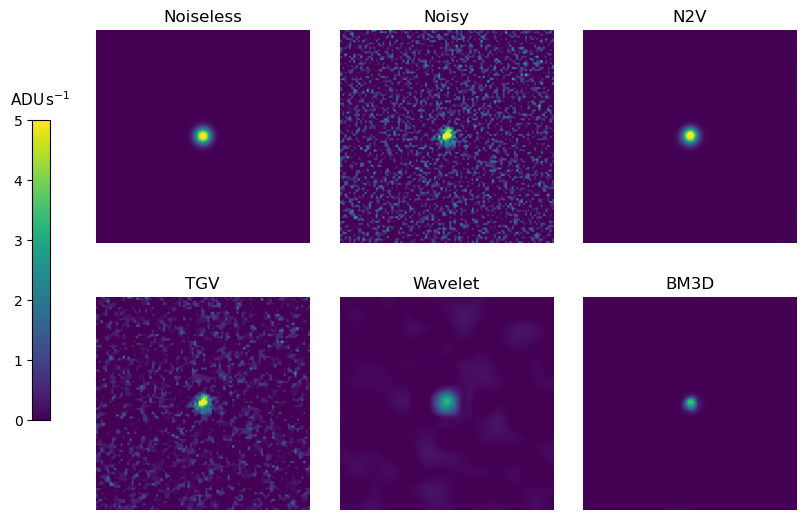

In [9]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9, 6)) 
axes = axes.flatten()

img_data_list = [
    stamps_cle[num],
    stamps_ori[num],
    n2vResult,
    imgs[3].cpu().squeeze().numpy(),
    imgs[4].cpu().squeeze().numpy(),
    imgs[2].cpu().squeeze().numpy()
]
titles = ['Noiseless', 'Noisy', 'N2V', 'TGV', 'Wavelet', 'BM3D']

global_vmin = 0#min(np.nanmin(img) for img in img_data_list)
global_vmax = 5#max(np.nanmax(img) for img in img_data_list)

for i in range(6):
    im = axes[i].imshow(img_data_list[i], vmin=global_vmin, vmax=global_vmax)
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].axis('off')
    
    if i == 2:
        target_im = im


plt.subplots_adjust(left=0.1, bottom=0.1, top=0.9, hspace=0.25, wspace=0.05)

cbar_ax = fig.add_axes([0.04, 0.25, 0.02, 0.5])

cbar = fig.colorbar(target_im, cax=cbar_ax)

cbar_ax.yaxis.set_ticks_position('left')
cbar.ax.tick_params(labelsize=10)

title = cbar.ax.set_title(r'$\mathrm{ADU}\,\mathrm{s}^{-1}$', fontsize=11, pad=10, ha='center')
title.set_x(0.45)

plt.show()